# Querying antigen-annotated T-cell receptors

This tutorial shows how to load Gene Expression, Antigen Capture (BEAM-T), TCR, and antigen-specificity score outputs from a public 10x Genomics dataset, combine the GEX and AIRR modalities in a {class}`~mudata.MuData` object, define exact paired-receptor groups with Scirpy, build a deterministic EBV-enriched reference subset, and query the remaining cells against it.

We use the public 10x Genomics **10k Human A1101 PBMCs with EBV Spike In (BEAM-T)** dataset, which contains human PBMCs, a `HLA-A*11:01`-restricted assay, and expanded anti-EBV T cells spiked into donor PBMCs. The assayed peptides are EBV `AVFDRKSDAK`, CMV `NLVPMVATV`, and a `HLA-A*11:01` negative-control peptide.

This tutorial keeps `EBV_score` and `CMV_score` as continuous metadata throughout. The illustrative threshold of **90** is used only to define a conservative EBV reference subset with `EBV_score >= 90` and `EBV_umi > 0`. Under that illustrative convention, this dataset contains a high-scoring EBV population from the spike-in, but no corresponding high-scoring CMV population.

**Sources and attribution**

- [10x Genomics dataset page](https://www.10xgenomics.com/datasets/10k-human-a1101-pbmcs-with-ebv-spike-in-beam-t-2-standard)
- [Cell Ranger Antigen Capture algorithm](https://www.10xgenomics.com/support/software/cell-ranger/latest/algorithms-overview/cr-5p-antigen-algorithm)
- [Cell Ranger per-sample output tables](https://www.10xgenomics.com/support/software/cell-ranger/latest/analysis/outputs/cr-5p-outputs-per-sample-outs-multi)
- [10x Loupe worked example using an antigen-specificity threshold of 90](https://www.10xgenomics.com/support/software/loupe-vdj-browser/latest/tutorials/lvb-integrated-analysis-loupe-browser)
- Dataset license: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)
- Scirpy functions used in this notebook are documented on the {doc}`../tutorials` page and in the API reference.


In [1]:
# Hidden documentation setup: data retrieval and warning suppression.
import os
import warnings
from pathlib import Path

import pooch

warnings.filterwarnings(
    "ignore",
    message=r"`__version__` is deprecated, use `importlib\.metadata\.version\('scanpy'\)` instead",
    category=FutureWarning,
)
warnings.filterwarnings("ignore", message=r"Variable names are not unique.*", category=UserWarning)
warnings.filterwarnings(
    "ignore",
    message=r"Support for Awkward Arrays is currently experimental\. Behavior may change in the future\. Please report any issues you may encounter!",
)

CACHE_DIR = Path(os.environ.get("SCIRPY_DATA_DIR") or pooch.os_cache("scirpy")) / "tutorial-beam-t-query"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
BASE_URL = (
    "https://cf.10xgenomics.com/samples/cell-vdj/7.1.0/"
    "10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2/"
)
FILES = {
    "gex_h5": (
        "10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_count_sample_filtered_feature_bc_matrix.h5",
        "284b22a51ec6048d14ffd6f26db09e8769bd694623982e0e8aaa5bae69d38ed5",
    ),
    "vdj_csv": (
        "10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_vdj_t_filtered_contig_annotations.csv",
        "3113306fa032e5b3d20d109557e04240d32c3903452d5ad154a940a68f120dca",
    ),
    "antigen_scores": (
        "10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_antigen_analysis_antigen_specificity_scores.csv",
        "2b3302ac64bc6049d2117095c9dbd0d301d777ca30367b9d3fd96157720c6be0",
    ),
}
paths = {
    key: Path(
        pooch.retrieve(
            url=BASE_URL + filename,
            known_hash=f"sha256:{sha256}",
            path=CACHE_DIR,
            fname=filename,
            progressbar=False,
        )
    )
    for key, (filename, sha256) in FILES.items()
}


## Imports and settings

In [2]:
import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import scirpy as ir

mu.set_options(pull_on_update=False)

BEAM_SCORE_THRESHOLD = 90.0
FULL_PAIR_CATEGORIES = ["single pair", "extra VJ", "extra VDJ", "two full chains"]
EXACT_GROUP_DISTANCE_KEY = "ir_dist_beam_t_exact_groups"
QUERY_DISTANCE_KEY = "ir_dist_beam_t_query_aa_identity"
QUERY_KEY = "ir_query_beam_t_query_aa_identity"


## Load GEX, Antigen Capture, and TCR data

The Gene Expression matrix contains all 9,798 detected cells, whereas the TCR modality contains the 5,643 barcodes with TCR contigs. We read the 10x feature matrix, the filtered TCR contig annotations, and the antigen-specificity score table, then attach the antigen-score metadata to the AIRR modality.


In [3]:
adata_gex = sc.read_10x_h5(paths["gex_h5"], gex_only=False)
adata_gex.var_names_make_unique()
adata_airr = ir.io.read_10x_vdj(paths["vdj_csv"])
mdata = mu.MuData({"gex": adata_gex, "airr": adata_airr})

scores = pd.read_csv(paths["antigen_scores"])
antigen_table = (
    scores.pivot(index="barcode", columns="antigen", values=["antigen_specificity_score", "antigen_umi", "control_umi"])
    .pipe(lambda df: df.set_axis([f"{antigen}_{field}" for field, antigen in df.columns], axis=1))
    .rename(
        columns={
            "EBV_antigen_specificity_score": "EBV_score",
            "CMV_antigen_specificity_score": "CMV_score",
            "EBV_antigen_umi": "EBV_umi",
            "CMV_antigen_umi": "CMV_umi",
        }
    )
    .assign(negative_control_umi=lambda df: df["EBV_control_umi"])
    .drop(columns=["EBV_control_umi", "CMV_control_umi"])
    .reset_index()
)
for column in antigen_table.columns:
    if column != "barcode":
        mdata.mod["airr"].obs[column] = antigen_table.set_index("barcode")[column].reindex(mdata.mod["airr"].obs_names)

pd.DataFrame({"cells": [mdata.mod["gex"].n_obs, mdata.mod["airr"].n_obs]}, index=["gex", "airr"])


,cells
gex,9798
airr,5643


## Visualize continuous antigen-score distributions

The threshold of **90** is an illustrative choice taken from an official 10x worked example. Here it is used only to define a conservative EBV reference subset with `EBV_score >= 90` and `EBV_umi > 0`.

CMV remains an assayed comparator rather than the assay control, and the assay control is `negative_control`. Under this illustrative convention, the dataset contains a high-scoring EBV population from the spike-in but no corresponding high-scoring CMV population.


,cells with score >= 90 and positive UMI,max score,median score
EBV,1147,100.000,0.159
CMV,0,24.634,0.042


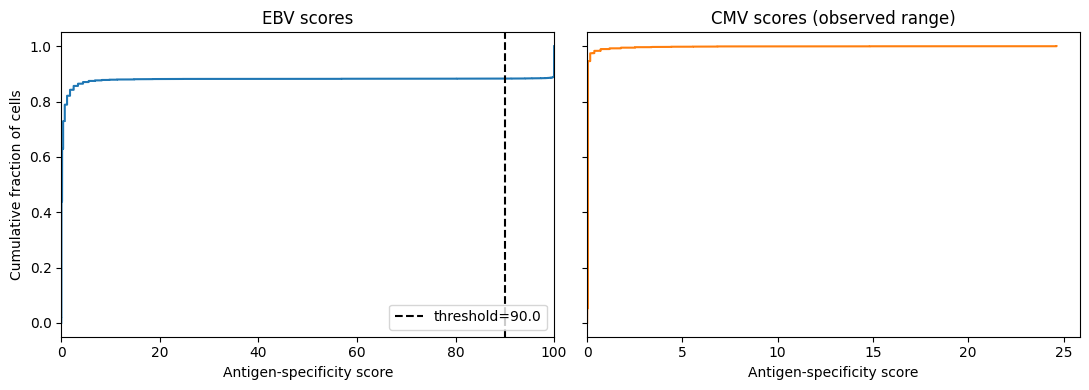

In [4]:
display(
    pd.DataFrame(
        {
            "cells with score >= 90 and positive UMI": [
                int(((antigen_table["EBV_score"] >= BEAM_SCORE_THRESHOLD) & antigen_table["EBV_umi"].gt(0)).sum()),
                int(((antigen_table["CMV_score"] >= BEAM_SCORE_THRESHOLD) & antigen_table["CMV_umi"].gt(0)).sum()),
            ],
            "max score": [antigen_table["EBV_score"].max(), antigen_table["CMV_score"].max()],
            "median score": [antigen_table["EBV_score"].median(), antigen_table["CMV_score"].median()],
        },
        index=["EBV", "CMV"],
    )
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, values, title, xmax, color in [
    (axes[0], antigen_table["EBV_score"], "EBV scores", 100, "#1f77b4"),
    (axes[1], antigen_table["CMV_score"], "CMV scores (observed range)", antigen_table["CMV_score"].max() * 1.05, "#ff7f0e"),
]:
    clean = np.sort(values.dropna().to_numpy(dtype=float))
    ax.step(clean, np.arange(1, clean.size + 1) / clean.size, where="post", color=color)
    ax.set_xlim(0, xmax)
    ax.set_title(title)
    ax.set_xlabel("Antigen-specificity score")
axes[0].axvline(BEAM_SCORE_THRESHOLD, linestyle="--", color="black", label=f"threshold={BEAM_SCORE_THRESHOLD}")
axes[0].set_ylabel("Cumulative fraction of cells")
axes[0].legend(loc="lower right")
fig.tight_layout()


## Index receptor chains, run QC, and define exact receptor groups

We now apply Scirpy's receptor model explicitly with {func}`scirpy.pp.index_chains` followed by {func}`scirpy.tl.chain_qc`. For this tutorial, eligible query cells are the cells with `receptor_subtype == "TRA+TRB"` and one of the full-pair `chain_pairing` categories.

To define exact paired-receptor groups in a way that matches the later query, we run {func}`scirpy.pp.ir_dist` and {func}`scirpy.tl.define_clonotype_clusters` on the full AIRR dataset with `sequence="aa"`, `metric="identity"`, `cutoff=0`, `receptor_arms="all"`, `dual_ir="primary_only"`, and `same_v_gene=False`.


In [5]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)
ir.pp.ir_dist(mdata, sequence="aa", metric="identity", cutoff=0, key_added=EXACT_GROUP_DISTANCE_KEY)
ir.tl.define_clonotype_clusters(
    mdata,
    sequence="aa",
    metric="identity",
    receptor_arms="all",
    dual_ir="primary_only",
    same_v_gene=False,
    key_added="exact_receptor_group",
    distance_key=EXACT_GROUP_DISTANCE_KEY,
)

mdata.mod["airr"].obs["barcode"] = mdata.mod["airr"].obs_names.astype(str)
airr_obs = mdata.mod["airr"].obs.copy()
airr_obs["query_suitable"] = airr_obs["receptor_subtype"].eq("TRA+TRB") & airr_obs["chain_pairing"].isin(FULL_PAIR_CATEGORIES)
query_suitable = airr_obs.loc[airr_obs["query_suitable"]].copy()
query_suitable["conservative_ebv_reference"] = query_suitable["EBV_score"].ge(BEAM_SCORE_THRESHOLD) & query_suitable["EBV_umi"].gt(0)

display(pd.DataFrame({"cells": [mdata.mod["gex"].n_obs, mdata.mod["airr"].n_obs, query_suitable.shape[0]]}, index=["GEX", "AIRR", "query-suitable AIRR"]))
display(query_suitable["chain_pairing"].value_counts().reindex(FULL_PAIR_CATEGORIES, fill_value=0).rename_axis("chain pairing").to_frame("cells"))
display(pd.DataFrame({"cells": [query_suitable.shape[0], int(query_suitable["conservative_ebv_reference"].sum()), int((~query_suitable["conservative_ebv_reference"]).sum())]}, index=["query-suitable cells", "query-suitable EBV cells", "query-suitable remaining cells"]))


,cells
GEX,9798
AIRR,5643
query-suitable AIRR,5078


,cells
chain pairing,
single pair,4310
extra VJ,526
extra VDJ,123
two full chains,119


,cells
query-suitable cells,5078
query-suitable EBV cells,362
query-suitable remaining cells,4716


## Build the reference and query datasets

Reference candidates are the eligible cells that meet the conservative EBV convention. For each Scirpy-defined `exact_receptor_group`, we select the **lexicographically smallest barcode** as a deterministic representative. All remaining eligible cells become the query set.

This is a practical subset-against-subset receptor query within one dataset. Exact receptor identity can support biological follow-up, but it does **not** prove antigen specificity.


In [6]:
reference_barcodes = (
    query_suitable.loc[query_suitable["conservative_ebv_reference"]]
    .sort_values(["exact_receptor_group", "barcode"])
    .drop_duplicates("exact_receptor_group")
    .index
)
query_barcodes = query_suitable.index.difference(reference_barcodes, sort=False)
reference = mdata[reference_barcodes, :].copy()
query = mdata[query_barcodes, :].copy()

display(pd.DataFrame({"cells": [reference.n_obs, query.n_obs], "unique exact receptor groups": [reference.mod["airr"].obs["exact_receptor_group"].nunique(), query.mod["airr"].obs["exact_receptor_group"].nunique()]}, index=["reference", "query"]))


,cells,unique exact receptor groups
reference,110,110
query,4968,4409


## Query the reference receptors

We now query the remaining cells against the internal reference using exact amino-acid identity with the same receptor settings that defined `exact_receptor_group`.


In [7]:
ir.pp.ir_dist(query, reference, sequence="aa", metric="identity", cutoff=0, key_added=QUERY_DISTANCE_KEY)
ir.tl.ir_query(
    query,
    reference,
    sequence="aa",
    metric="identity",
    receptor_arms="all",
    dual_ir="primary_only",
    same_v_gene=False,
    match_columns=None,
    distance_key=QUERY_DISTANCE_KEY,
    key_added=QUERY_KEY,
)
pairs = ir.tl.ir_query_annotate_df(
    query,
    reference,
    sequence="aa",
    metric="identity",
    include_query_cols=["barcode", "EBV_score", "CMV_score", "EBV_umi", "CMV_umi", "negative_control_umi", "exact_receptor_group"],
    include_ref_cols=["barcode", "EBV_score", "CMV_score", "EBV_umi", "CMV_umi", "negative_control_umi", "exact_receptor_group"],
    suffix="_ref",
    query_key=QUERY_KEY,
).rename(columns={"barcode_ref": "reference_barcode"})

matched_barcodes = pairs.index.unique()
query.mod["airr"].obs["match_status"] = pd.Categorical(
    np.where(query.mod["airr"].obs_names.isin(matched_barcodes), "matched", "unmatched"),
    categories=["matched", "unmatched"],
)
query.mod["airr"].obs["query_score_group"] = pd.Categorical(
    np.where(
        query.mod["airr"].obs["EBV_score"].ge(BEAM_SCORE_THRESHOLD) & query.mod["airr"].obs["EBV_umi"].gt(0),
        "EBV score >= 90 with EBV UMI > 0",
        "other query-suitable cells",
    ),
    categories=["other query-suitable cells", "EBV score >= 90 with EBV UMI > 0"],
)

display(pairs[["reference_barcode", "EBV_score", "EBV_score_ref", "CMV_score", "CMV_score_ref", "exact_receptor_group"]].head(10))


,reference_barcode,EBV_score,EBV_score_ref,CMV_score,CMV_score_ref,exact_receptor_group
AACACGTCACCAGTTA-1,CTGCCTAGTCTCACCT-1,0.042,100.0,0.042,0.042,65
AACGTTGAGCCGCCTA-1,CATATGGTCACGGTTA-1,0.042,100.0,0.042,0.042,92
AACGTTGGTCACCTAA-1,AACACGTCAGTAAGCG-1,100.000,100.0,0.042,0.159,66
AACGTTGGTTGGACCC-1,CATATGGTCACGGTTA-1,0.042,100.0,0.042,0.042,92
AACTCAGGTAAACGCG-1,AACACGTCAGTAAGCG-1,100.000,100.0,0.000,0.159,66
AAGCCGCGTGCGGTAA-1,AACACGTCAGTAAGCG-1,100.000,100.0,0.042,0.159,66
AAGGCAGCAGAGCCAA-1,CATATGGTCACGGTTA-1,0.376,100.0,0.042,0.042,92
AATCCAGTCATATCGG-1,AACACGTCAGTAAGCG-1,100.000,100.0,0.042,0.159,66
ACACCAAAGGGAGTAA-1,CATATGGTCACGGTTA-1,0.042,100.0,0.042,0.042,92
ACACCAAAGTACATGA-1,AACACGTCAGTAAGCG-1,100.000,100.0,0.060,0.159,66


## Summarize query results

{func}`scirpy.tl.ir_query_annotate_df` returns the complete query/reference match-pair table. Match pairs and unique matched query cells are therefore counted separately.


,value
GEX cells,9798
AIRR cells,5643
query-suitable cells,5078
query-suitable EBV cells,362
query-suitable remaining cells,4716
reference cells,110
query cells,4968
match pairs,357
unique matched query cells,357
matched EBV query cells,252


query_score_group,other query-suitable cells,EBV score >= 90 with EBV UMI > 0
match_status,,
matched,105.0,252.0
unmatched,4611.0,0.0


<Axes: title={'center': 'Number of cells in match_status by query_score_group'}, xlabel='match_status', ylabel='Number of cells'>

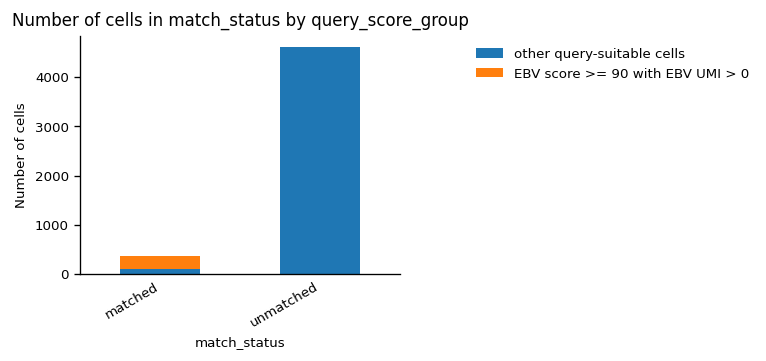

In [8]:
display(
    pd.DataFrame(
        {
            "value": [
                mdata.mod["gex"].n_obs,
                mdata.mod["airr"].n_obs,
                query_suitable.shape[0],
                int(query_suitable["conservative_ebv_reference"].sum()),
                int((~query_suitable["conservative_ebv_reference"]).sum()),
                reference.n_obs,
                query.n_obs,
                len(pairs),
                len(matched_barcodes),
                int(query.mod["airr"].obs.loc[matched_barcodes, "query_score_group"].eq("EBV score >= 90 with EBV UMI > 0").sum()),
                int(query.mod["airr"].obs.loc[matched_barcodes, "query_score_group"].eq("other query-suitable cells").sum()),
                query.n_obs - len(matched_barcodes),
                int((pairs.groupby(level=0)["reference_barcode"].nunique() > 1).sum()),
            ]
        },
        index=[
            "GEX cells",
            "AIRR cells",
            "query-suitable cells",
            "query-suitable EBV cells",
            "query-suitable remaining cells",
            "reference cells",
            "query cells",
            "match pairs",
            "unique matched query cells",
            "matched EBV query cells",
            "matched remaining query cells",
            "unmatched query cells",
            "multiple-reference matches",
        ],
    )
)
display(ir.tl.group_abundance(query.mod["airr"], groupby="match_status", target_col="query_score_group", sort="alphabetical"))
ir.pl.group_abundance(query.mod["airr"], groupby="match_status", target_col="query_score_group", sort="alphabetical")


## Interpretation and limitations

- The threshold of 90 is illustrative and dataset-specific. Here it is used only to choose a conservative EBV reference subset.
- Continuous EBV and CMV scores are retained throughout. Cells below the conservative EBV convention are not antigen negative.
- CMV is an assayed comparator, while `negative_control` is the assay control.
- This dataset contains an EBV-specific spike-in and no high-scoring CMV population under the illustrative convention used here.
- Exact receptor identity and `exact_receptor_group` membership do not prove antigen specificity.
- The selected reference cell is only a deterministic representative for its exact receptor group.
- This tutorial demonstrates a subset-against-subset receptor query within one dataset, not an independent predictive validation.
- No sensitivity, specificity, or predictive accuracy is estimated.
